# OrcaFlex simulaties voor vier damping cases

Deze notebook runt één OrcaFlex model voor meerdere sea states. Voor elke sea state worden de vier damping cases uit de tabel doorgerekend. Daarna worden **heave**, **pitch** en **roll** als overlay geplot, waarbij alle vier cases in één plot staan. De sea state staat in de titel van elke plot en alle plots worden opgeslagen als afbeelding.


In [1]:
# ============================================================
# 1. Imports
# ============================================================
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import OrcFxAPI


In [2]:
# ============================================================
# 2. Instellingen
# ============================================================

# PAS AAN: pad naar je OrcaFlex model
model_path = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Harlequin_spring_mooringtryout.dat")

# Namen zoals in je eerdere notebook
vesselname = "floaters"
vesseltypename = "floatertype"

# Outputmap voor afbeeldingen
output_dir = Path("orca_case_plots")
output_dir.mkdir(parents=True, exist_ok=True)

# Sea states: voeg hier zelf condities toe of pas ze aan
# Hs = wave height [m]
# Tp = wave period [s]
sea_conditions = [
    {"Hs": 4.0, "Tp": 7.04, "direction": 180.0, "wave_type": "Dean stream"},
    # {"Hs": 5.0, "Tp": 8.0, "direction": 180.0, "wave_type": "Dean stream"},
]

# Plotinstellingen
plot_start_time = 0.0       # [s]
analysis_start_time = 0.0   # [s]
show_plots = True           # True = toon plots in notebook
save_plots = True           # True = sla plots op als .png


In [3]:
# ============================================================
# 3. Damping cases uit de tabel
# ============================================================

DAMPING_CASES = {
    "1": {"heave": {"lin": 0.0, "quad": 0.0}, "pitch": {"lin": 0.0, "quad": 0.0}, "roll": {"lin": 0.0, "quad": 0.0}},
    "2": {"heave": {"lin": 7.0, "quad": 0.0}, "pitch": {"lin": 300.0, "quad": 0.0}, "roll": {"lin": 300.0, "quad": 0.0}},
    "3": {"heave": {"lin": 0.0, "quad": 5.0}, "pitch": {"lin": 175.0, "quad": 1200.0}, "roll": {"lin": 150.0, "quad": 1400.0}},
    "4": {"heave": {"lin": 4.0, "quad": 4.0}, "pitch": {"lin": 250.0, "quad": 1000.0}, "roll": {"lin": 250.0, "quad": 1000.0}},
}

DAMPING_CASES


{'1': {'heave': {'lin': 0.0, 'quad': 0.0},
  'pitch': {'lin': 0.0, 'quad': 0.0},
  'roll': {'lin': 0.0, 'quad': 0.0}},
 '2': {'heave': {'lin': 7.0, 'quad': 0.0},
  'pitch': {'lin': 300.0, 'quad': 0.0},
  'roll': {'lin': 300.0, 'quad': 0.0}},
 '3': {'heave': {'lin': 0.0, 'quad': 5.0},
  'pitch': {'lin': 175.0, 'quad': 1200.0},
  'roll': {'lin': 150.0, 'quad': 1400.0}},
 '4': {'heave': {'lin': 4.0, 'quad': 4.0},
  'pitch': {'lin': 250.0, 'quad': 1000.0},
  'roll': {'lin': 250.0, 'quad': 1000.0}}}

In [4]:
# ============================================================
# 4. Helper functies OrcaFlex
# ============================================================

def safe_name(text):
    # Maak een veilige bestandsnaam.
    text = str(text).replace(".", "p")
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", text)


def set_indexed_or_scalar(obj, name, value, index=0):
    # Zet OrcaFlex data die soms scalar en soms indexed/table data is.
    try:
        getattr(obj, name)[index] = value
    except Exception:
        setattr(obj, name, value)


def set_wave_condition(model, sea_state):
    # Zet de golfconditie voor één sea state.
    env = model.environment

    Hs = float(sea_state["Hs"])
    Tp = float(sea_state["Tp"])
    direction = float(sea_state.get("direction", 180.0))
    wave_type = sea_state.get("wave_type", "Dean stream")

    set_indexed_or_scalar(env, "WaveType", wave_type)
    set_indexed_or_scalar(env, "WaveHeight", Hs)
    set_indexed_or_scalar(env, "WavePeriod", Tp)
    set_indexed_or_scalar(env, "WaveDirection", direction)
    set_indexed_or_scalar(env, "WaveOriginX", 0.0)
    set_indexed_or_scalar(env, "WaveOriginY", 0.0)
    set_indexed_or_scalar(env, "WaveTimeOrigin", 0.0)


def reset_initial_position(vessel):
    # Zet initiële offsets terug naar nul.
    vessel.InitialX = 0.0
    vessel.InitialY = 0.0
    vessel.InitialZ = 0.0
    vessel.InitialHeel = 0.0
    vessel.InitialTrim = 0.0
    vessel.InitialHeading = 0.0


def set_case_damping(vesseltype, case):
    # Mapping: heave = Z, roll = Rx / Rotation 1, pitch = Ry / Rotation 2.
    vesseltype.OtherDampingLinearCoeffZ = float(case["heave"]["lin"])
    vesseltype.OtherDampingQuadraticCoeffZ = float(case["heave"]["quad"])

    vesseltype.OtherDampingLinearCoeffRy = float(case["pitch"]["lin"])
    vesseltype.OtherDampingQuadraticCoeffRy = float(case["pitch"]["quad"])

    vesseltype.OtherDampingLinearCoeffRx = float(case["roll"]["lin"])
    vesseltype.OtherDampingQuadraticCoeffRx = float(case["roll"]["quad"])


def run_orcaflex_case(model_path, sea_state, case):
    # Laadt model, zet sea state en damping case, runt simulatie en leest responses uit.
    model = OrcFxAPI.Model(str(model_path))

    vessel = model[vesselname]
    vesseltype = model[vesseltypename]

    reset_initial_position(vessel)
    set_wave_condition(model, sea_state)
    set_case_damping(vesseltype, case)

    model.RunSimulation()

    t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
    responses = {
        "heave": np.asarray(vessel.TimeHistory("Z"), dtype=float),
        "pitch": np.asarray(vessel.TimeHistory("Rotation 2"), dtype=float),
        "roll":  np.asarray(vessel.TimeHistory("Rotation 1"), dtype=float),
    }
    return t, responses


def response_metrics(t, y):
    # Bereken eenvoudige response metrics na analysis_start_time.
    t = np.asarray(t)
    y = np.asarray(y)
    mask = t >= analysis_start_time
    z = y[mask]

    if len(z) == 0:
        return {"mean": np.nan, "std": np.nan, "rms": np.nan, "max_abs": np.nan, "ptp": np.nan}

    return {
        "mean": float(np.mean(z)),
        "std": float(np.std(z)),
        "rms": float(np.sqrt(np.mean(z**2))),
        "max_abs": float(np.max(np.abs(z))),
        "ptp": float(np.ptp(z)),
    }


In [5]:
# ============================================================
# 5. Simulaties runnen
# ============================================================

all_time_histories = {}
metrics_rows = []

for sea_i, sea_state in enumerate(sea_conditions, start=1):
    Hs = float(sea_state["Hs"])
    Tp = float(sea_state["Tp"])
    direction = float(sea_state.get("direction", 180.0))
    wave_type = sea_state.get("wave_type", "Dean stream")
    sea_key = f"Hs{Hs:g}_Tp{Tp:g}_Dir{direction:g}"

    print("=" * 90)
    print(f"Sea state {sea_i}: Hs={Hs:g} m, Tp={Tp:g} s, direction={direction:g} deg, wave_type={wave_type}")
    print("=" * 90)

    for case_name, case in DAMPING_CASES.items():
        print(f"Running case {case_name}...")
        try:
            t, responses = run_orcaflex_case(model_path, sea_state, case)
            all_time_histories[(sea_key, case_name)] = {"t": t, **responses}

            for response_name, y in responses.items():
                m = response_metrics(t, y)
                metrics_rows.append({
                    "sea_key": sea_key,
                    "Hs_m": Hs,
                    "Tp_s": Tp,
                    "direction_deg": direction,
                    "wave_type": wave_type,
                    "case": case_name,
                    "response": response_name,
                    "status": "ok",
                    **m,
                })
        except Exception as e:
            print(f"FAILED sea state {sea_key}, case {case_name}: {e}")
            for response_name in ["heave", "pitch", "roll"]:
                metrics_rows.append({
                    "sea_key": sea_key,
                    "Hs_m": Hs,
                    "Tp_s": Tp,
                    "direction_deg": direction,
                    "wave_type": wave_type,
                    "case": case_name,
                    "response": response_name,
                    "status": "failed",
                    "error": str(e),
                    "mean": np.nan,
                    "std": np.nan,
                    "rms": np.nan,
                    "max_abs": np.nan,
                    "ptp": np.nan,
                })

metrics_df = pd.DataFrame(metrics_rows)
metrics_df


Sea state 1: Hs=4 m, Tp=7.04 s, direction=180 deg, wave_type=Dean stream
Running case 1...
Running case 2...
Running case 3...
Running case 4...


,sea_key,Hs_m,Tp_s,direction_deg,wave_type,case,response,status,mean,std,rms,max_abs,ptp
0,Hs4_Tp7.04_Dir180,4.0,7.04,180.0,Dean stream,1,heave,ok,-0.038146,1.439549,1.440054,3.451673,6.559276
1,Hs4_Tp7.04_Dir180,4.0,7.04,180.0,Dean stream,1,pitch,ok,0.067474,18.038290,18.038416,38.801109,73.301375
2,Hs4_Tp7.04_Dir180,4.0,7.04,180.0,Dean stream,1,roll,ok,0.445301,14.757257,14.763974,36.740202,71.805827
3,Hs4_Tp7.04_Dir180,4.0,7.04,180.0,Dean stream,2,heave,ok,-0.016885,1.289137,1.289247,2.952490,5.528221
4,Hs4_Tp7.04_Dir180,4.0,7.04,180.0,Dean stream,2,pitch,ok,0.553200,15.815575,15.825247,30.460677,59.903976
5,Hs4_Tp7.04_Dir180,4.0,7.04,180.0,Dean stream,2,roll,ok,0.134876,11.606777,11.607560,29.839041,58.140787
6,Hs4_Tp7.04_Dir180,4.0,7.04,180.0,Dean stream,3,heave,ok,-0.030897,1.276221,1.276595,2.732745,4.983053
7,Hs4_Tp7.04_Dir180,4.0,7.04,180.0,Dean stream,3,pitch,ok,0.428991,14.868204,14.874391,27.026779,53.675426
8,Hs4_Tp7.04_Dir180,4.0,7.04,180.0,Dean stream,3,roll,ok,0.260380,9.968031,9.971431,27.424721,51.801406
9,Hs4_Tp7.04_Dir180,4.0,7.04,180.0,Dean stream,4,heave,ok,-0.027522,1.270822,1.271120,2.697791,4.898370


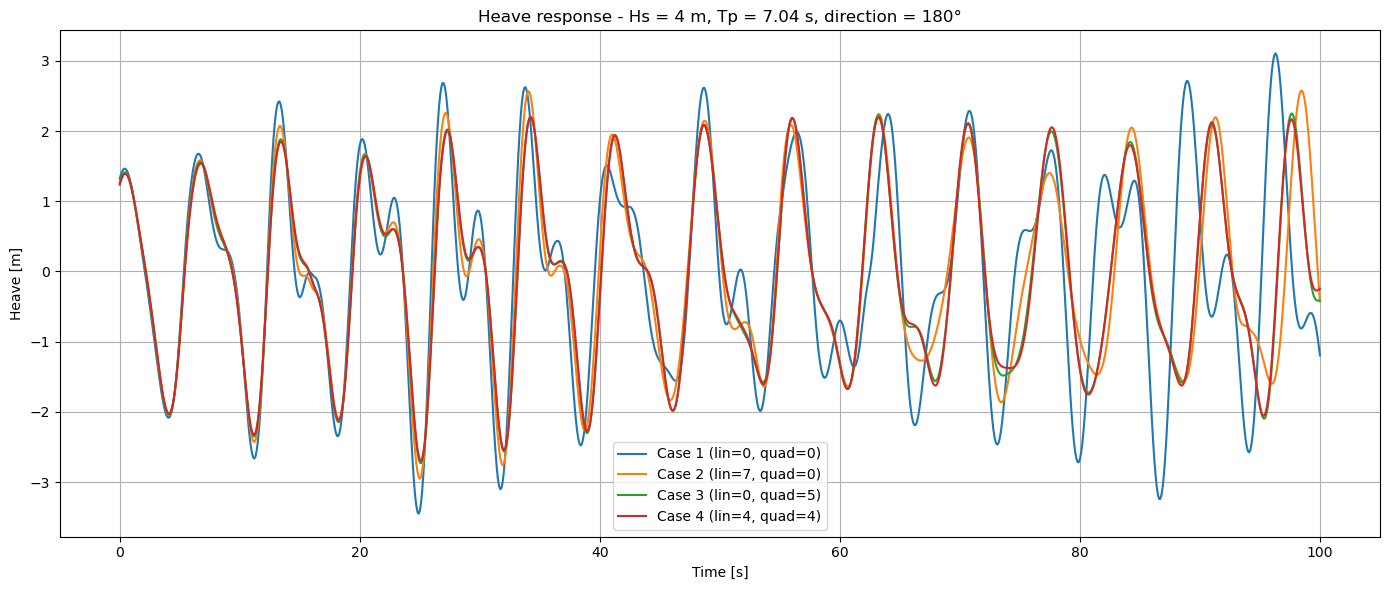

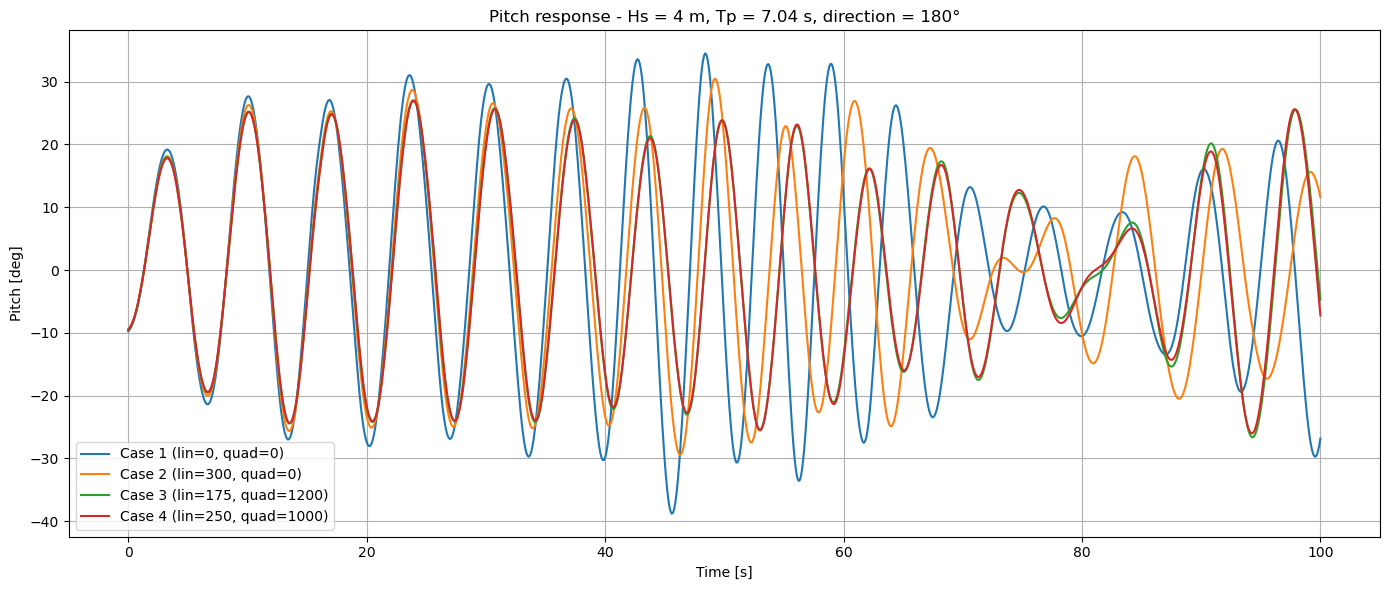

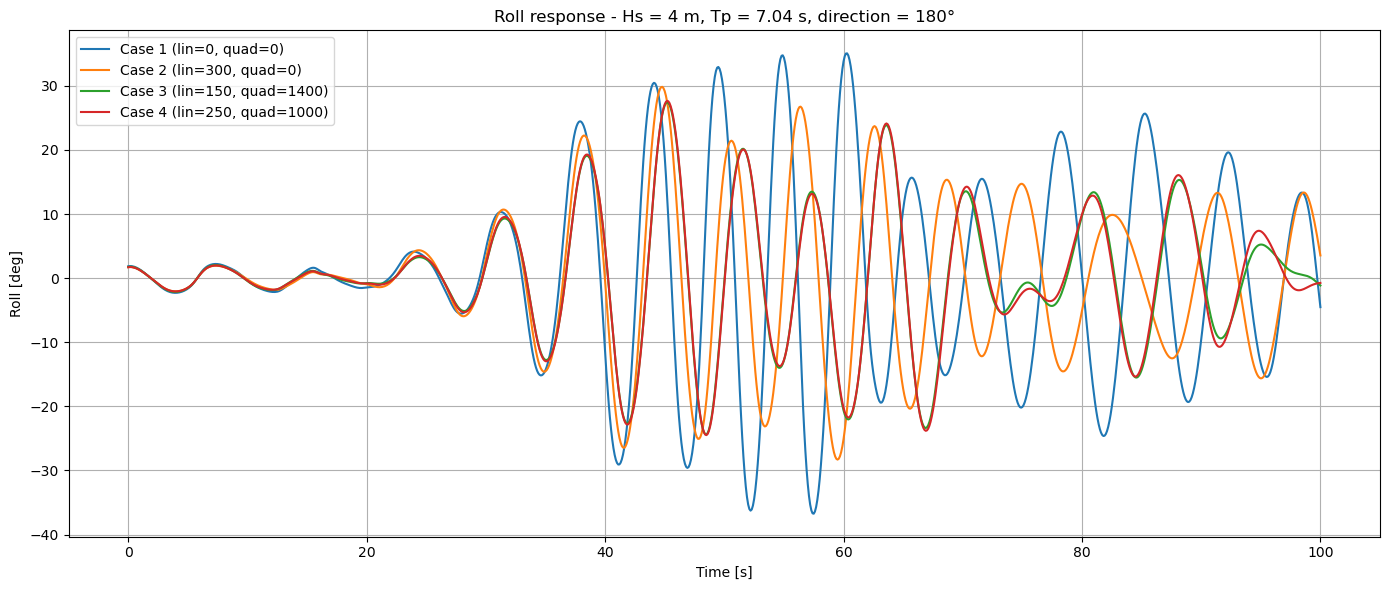

Opgeslagen figuren:
orca_case_plots\Hs4_Tp7p04_Dir180_heave_cases.png
orca_case_plots\Hs4_Tp7p04_Dir180_pitch_cases.png
orca_case_plots\Hs4_Tp7p04_Dir180_roll_cases.png


In [6]:
# ============================================================
# 6. Plots: per sea state en per response alle cases in één plot
# ============================================================

response_labels = {
    "heave": ("Heave", "Heave [m]"),
    "pitch": ("Pitch", "Pitch [deg]"),
    "roll":  ("Roll", "Roll [deg]"),
}

saved_figures = []

for sea_i, sea_state in enumerate(sea_conditions, start=1):
    Hs = float(sea_state["Hs"])
    Tp = float(sea_state["Tp"])
    direction = float(sea_state.get("direction", 180.0))
    sea_key = f"Hs{Hs:g}_Tp{Tp:g}_Dir{direction:g}"

    for response_name, (response_title, ylabel) in response_labels.items():
        fig, ax = plt.subplots(figsize=(14, 6))

        for case_name in DAMPING_CASES.keys():
            key = (sea_key, case_name)
            if key not in all_time_histories:
                continue

            data = all_time_histories[key]
            t = data["t"]
            y = data[response_name]
            mask = t >= plot_start_time

            case = DAMPING_CASES[case_name]
            label = f"Case {case_name} (lin={case[response_name]['lin']:g}, quad={case[response_name]['quad']:g})"
            ax.plot(t[mask], y[mask], linewidth=1.5, label=label)

        ax.set_xlabel("Time [s]")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{response_title} response - Hs = {Hs:g} m, Tp = {Tp:g} s, direction = {direction:g}°")
        ax.grid(True)
        ax.legend()
        fig.tight_layout()

        if save_plots:
            filename = output_dir / f"{safe_name(sea_key)}_{response_name}_cases.png"
            fig.savefig(filename, dpi=300, bbox_inches="tight")
            saved_figures.append(filename)

        if show_plots:
            plt.show()
        else:
            plt.close(fig)

print("Opgeslagen figuren:")
for f in saved_figures:
    print(f)


In [7]:
# ============================================================
# 7. Metrics opslaan
# ============================================================

metrics_path = output_dir / "response_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"Metrics opgeslagen naar: {metrics_path}")


Metrics opgeslagen naar: orca_case_plots\response_metrics.csv
